# Acoustic Telemetry Animal Tracking

This notebook implements the correlated random walk (CRW) state-space model from Lavender et al. 2026 using dynestyx. The model tracks a fish on a synthetic rectangular lake using binary acoustic detections at 15 hydrophone receivers.

The pipeline:
1. Forward simulate a ground-truth trajectory from the CRW model
2. Feed the simulated detections into a bootstrap particle filter + tracing smoother
3. Compare the smoothed posterior to the true trajectory visually
4. Compute region residency for the true trajectory and the posterior, and evaluate accuracy

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx import DiscreteTimeSimulator, Smoother
from dynestyx.inference.smoother_configs import PFSmootherConfig

from animal_movement import make_synthetic_lake, animal_movement_model

# Reproducibility
KEY = jr.PRNGKey(42)

## 1. Domain setup

In [2]:
domain = make_synthetic_lake()
print(f"Lake: {domain.width/1000:.0f} km × {domain.height/1000:.0f} km")
print(f"Receivers: {domain.n_receivers}")
print(f"Regions: {len(domain.region_boundaries) + 1}")

Lake: 20 km × 50 km
Receivers: 15
Regions: 5


## 2. Simulate a ground-truth trajectory

We run the model forward for T = 100 two-minute steps (3 hours 20 minutes).

In [3]:
T = 100
obs_times = jnp.arange(T, dtype=float)

KEY, sim_key = jr.split(KEY)

with DiscreteTimeSimulator(n_simulations=1):
    pred = Predictive(
        animal_movement_model,
        params={},
        num_samples=1,
        exclude_deterministic=False,
    )
    sim_out = pred(sim_key, domain=domain, predict_times=obs_times)

# sim_out shapes: f_states (1, 1, T, 3), f_observations (1, 1, T, K)
true_states = sim_out["f_states"][0, 0]         # (T, 3)
observations = sim_out["f_observations"][0, 0]  # (T, K)  binary

print(f"True states shape: {true_states.shape}")
print(f"Observations shape: {observations.shape}")
print(f"Total detections: {int(observations.sum())} / {T * domain.n_receivers} possible")

True states shape: (100, 3)
Observations shape: (100, 15)
Total detections: 1 / 1500 possible


## 3. Run the bootstrap PF + tracing smoother

The tracing smoother never evaluates the CRW transition density, so CRWStep only needs to implement `sample()`.

In [4]:
smoother_config = PFSmootherConfig(
    n_particles=500,
    pf_backward_sampling_method="tracing",
    pf_n_smoother_particles=200,
    record_smoothed_particles=True,
    record_smoothed_states_mean=True,
)

KEY, smoother_key = jr.split(KEY)

with DiscreteTimeSimulator(n_simulations=1):
    with Smoother(smoother_config=smoother_config):
        smoother_pred = Predictive(
            animal_movement_model,
            params={},
            num_samples=1,
            exclude_deterministic=False,
        )
        smoother_out = smoother_pred(
            smoother_key,
            domain=domain,
            obs_times=obs_times,
            obs_values=observations,
        )

# particles shape: (num_samples, T, n_smoother_particles, 3)
# mean shape:      (num_samples, T, 3)
particles = smoother_out["f_smoothed_particles"][0]   # (T, N_s, 3)
mean_traj = smoother_out["f_smoothed_states_mean"][0] # (T, 3)

print(f"Smoothed particles shape: {particles.shape}")
print(f"Posterior mean shape:     {mean_traj.shape}")

Smoothed particles shape: (100, 200, 3)
Posterior mean shape:     (100, 3)


## 4. Visual trajectory recovery

Grey cloud: smoothed particle positions. Blue line: posterior mean path. Red line: true path. Stars: hydrophone receivers.

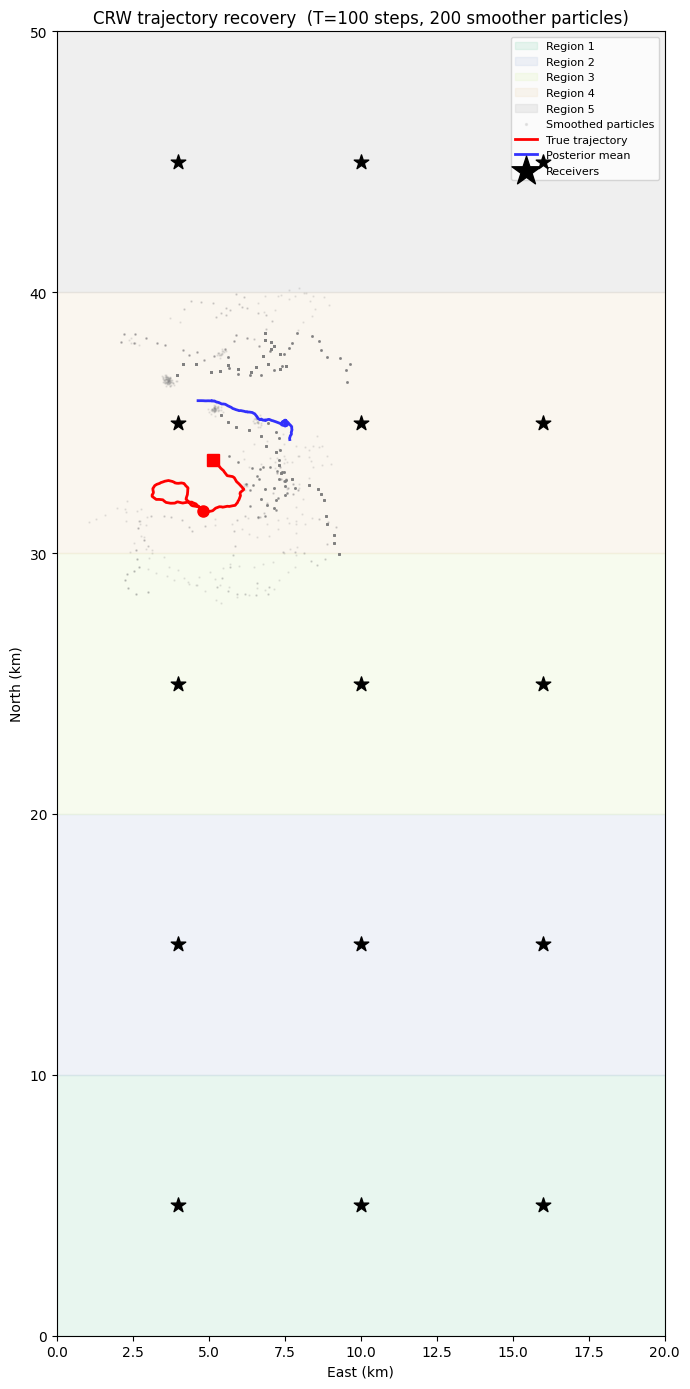

In [5]:
fig, ax = plt.subplots(figsize=(7, 14))

# Region boundaries as horizontal bands
region_ys = np.concatenate([[0.0], np.array(domain.region_boundaries), [domain.height]])
colors = plt.cm.Pastel2(np.linspace(0, 1, len(region_ys) - 1))
for i, (y0, y1) in enumerate(zip(region_ys[:-1], region_ys[1:])):
    ax.axhspan(y0 / 1000, y1 / 1000, alpha=0.3, color=colors[i], label=f"Region {i+1}")

# Smoothed particle cloud at every 5th time step
step = 5
pts = np.array(particles[::step])  # (T//step, N_s, 3)
x_pts = pts[:, :, 0].ravel() / 1000
y_pts = pts[:, :, 1].ravel() / 1000
ax.scatter(x_pts, y_pts, s=0.5, c="grey", alpha=0.15, label="Smoothed particles", rasterized=True)

# True trajectory
true_xy = np.array(true_states[:, :2]) / 1000
ax.plot(true_xy[:, 0], true_xy[:, 1], "r-", lw=2, label="True trajectory", zorder=5)
ax.plot(true_xy[0, 0], true_xy[0, 1], "ro", ms=8, zorder=6)
ax.plot(true_xy[-1, 0], true_xy[-1, 1], "rs", ms=8, zorder=6)

# Posterior mean
mean_xy = np.array(mean_traj[:, :2]) / 1000
ax.plot(mean_xy[:, 0], mean_xy[:, 1], "b-", lw=2, alpha=0.8, label="Posterior mean", zorder=5)

# Receivers
rx = np.array(domain.receiver_locs[:, 0]) / 1000
ry = np.array(domain.receiver_locs[:, 1]) / 1000
ax.scatter(rx, ry, marker="*", s=120, c="k", zorder=7, label="Receivers")

ax.set_xlim(0, domain.width / 1000)
ax.set_ylim(0, domain.height / 1000)
ax.set_xlabel("East (km)")
ax.set_ylabel("North (km)")
ax.set_title(f"CRW trajectory recovery  (T={T} steps, {smoother_config.pf_n_smoother_particles} smoother particles)")
ax.legend(loc="upper right", fontsize=8, markerscale=2)
plt.tight_layout()
plt.savefig("trajectory_recovery.png", dpi=150)
plt.show()

## 5. Residency accuracy

The primary evaluation metric from Lavender et al. 2026 is region residency: the fraction of time the fish spends in each north-south region. We compare the true residency against the posterior-mean estimate derived from the smoothed particles.

In [6]:
n_regions = len(domain.region_boundaries) + 1

# True region at each time step
true_regions = jax.vmap(lambda s: domain.region_index(s[:2]))(true_states)  # (T,)

# Posterior region for each particle at each time step: (T, N_s)
inferred_regions = jax.vmap(
    jax.vmap(lambda s: domain.region_index(s[:2]))
)(particles)

# Residency fractions
region_ids = jnp.arange(n_regions)
true_residency = jnp.mean(
    (true_regions[:, None] == region_ids[None, :]).astype(float), axis=0
)  # (n_regions,)

inferred_residency = jnp.mean(
    (inferred_regions[:, :, None] == region_ids[None, None, :]).astype(float),
    axis=(0, 1),
)  # (n_regions,)

print("Region residency (fraction of T steps)")
print(f"{'Region':>8}  {'True':>8}  {'Inferred':>10}  {'|Error|':>8}")
total_error = 0.0
for i in range(n_regions):
    err = abs(float(true_residency[i]) - float(inferred_residency[i]))
    total_error += err
    print(f"{i+1:>8}  {float(true_residency[i]):>8.3f}  {float(inferred_residency[i]):>10.3f}  {err:>8.3f}")
print(f"\nMean absolute error: {total_error / n_regions:.4f}")

Region residency (fraction of T steps)
  Region      True    Inferred   |Error|
       1     0.000       0.000     0.000
       2     0.000       0.000     0.000
       3     0.000       0.024     0.024
       4     1.000       0.975     0.025
       5     0.000       0.001     0.001

Mean absolute error: 0.0099


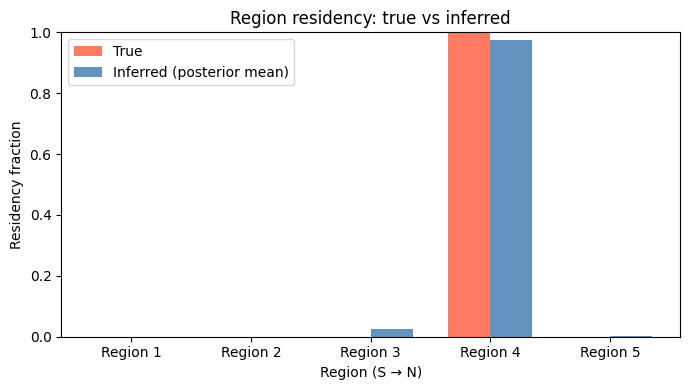

MAE = 0.0099  (chance level ~ 0.16 for 5 uniform regions)


In [7]:
fig, ax = plt.subplots(figsize=(7, 4))

x = np.arange(n_regions)
width = 0.35
ax.bar(x - width/2, np.array(true_residency), width, label="True", color="tomato", alpha=0.85)
ax.bar(x + width/2, np.array(inferred_residency), width, label="Inferred (posterior mean)", color="steelblue", alpha=0.85)

ax.set_xlabel("Region (S → N)")
ax.set_ylabel("Residency fraction")
ax.set_title("Region residency: true vs inferred")
ax.set_xticks(x)
ax.set_xticklabels([f"Region {i+1}" for i in range(n_regions)])
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("residency_accuracy.png", dpi=150)
plt.show()

mae = total_error / n_regions
print(f"MAE = {mae:.4f}  (chance level ~ 0.16 for 5 uniform regions)")